# DATA UNDERSTANDING AND PREPARATION

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay

In this step, we import the Python libraries required for data analysis, visualization, and machine learning.

- **`pandas`** – For loading, cleaning, and manipulating tabular data.  
- **`numpy`** – Provides support for numerical operations and arrays.  
- **`matplotlib.pyplot`** & **`seaborn`** – For creating plots and visualizations to explore and communicate data patterns.  

- **`sklearn.model_selection.train_test_split`** – To split the dataset into training and testing sets.  
- **`sklearn.linear_model.LogisticRegression`** – Logistic regression model for binary classification.  
- **`sklearn.ensemble.RandomForestClassifier`** – Random forest classifier for improved predictive performance.  
- **`sklearn.metrics`** (accuracy_score, confusion_matrix, roc_auc_score, RocCurveDisplay) – To evaluate model performance using metrics and visualizations.  

This sets up the environment for the entire analysis pipeline, from initial exploration to model building and evaluation.

### Load Excel File and Preview First 5 Rows

In [4]:
# Load Excel file and preview first 5 rows
df = pd.read_excel("data/default-of-credit-card-clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


- The dataset was loaded successfully using the pandas library.  
- The first few rows were displayed to confirm that the data imported correctly.  
- This preview helps identify any immediate issues, such as unusual values or formatting inconsistencies, before deeper exploration.

### Dataset Shape - Number of Rows and Columns

In [5]:
df.shape

(30000, 25)

- The dataset dimensions were examined, showing **30,000 rows (*clients*)** and **25 columns (*features*)**.  
- This confirms the dataset is large enough for reliable statistical and machine learning analysis.

### Dataset Column Names

In [6]:
df.columns 

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

The column names were reviewed to understand what each variable represents.

They include: 
- **account information - credit limit** (e.g. '`LIMIT_BAL`').  
- **client demographics** (e.g. '`SEX`', '`EDUCATION`', '`MARRIAGE`', '`AGE`').   
- **repayment statuses for the last 6 months** (e.g. '`PAY_0`' - '`PAY_6`').  
- **bill statements** (e.g. '`BILL_AMT1`' - '`BILLAMT6`').  
- **payments made** (e.g. '`PAY-AMT1`' - '`PAY_AMT6`').  
- **target variable** ('`default payment next month`').  

The target column - 'default payment next month' - indicates whether each client defaulted (1) or not (0).

This command is also a method of checking there are no typos or accidental spaces in the column names.

We also note that ID is a column which is unnecessary for modeling:

### Remove ID Column

In [7]:
df = df.drop(columns=['ID'], axis=1)

The `ID` column is a unique identifier for each row and does not provide any predictive information for our analysis.  
Therefore, we remove it from the dataset to avoid including irrelevant features in the model.  
Note that **we now have 24 columns** in lieu of 25.

### Dataset Information - Data Types, Non-Null Counts, Memory Usage

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

- All columns have **non-null values**, so there are **no missing values** in the dataset.  
- Every column is of type `int64`, meaning all variables are stored as **integers**.  
- Memory usage is around **5.7 MB**, which is manageable for typical analyses.  
- This overview confirms that the data is clean in terms of missing values and ready for further exploration.

### Missing Values in Dataset

In [9]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

*Missing data can cause errors or bias in statistical models and machine learning algorithms.*  
This command returns the total number of missing or null values in each column.  
The dataset is **clean with no missing entries**, so no data imputation or removal is necessary at this stage.

### Basic Statistics of Dataset - Min, Max, Standard Deviation, etc.

In [10]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


The `df.describe()` function provides a **statistical summary** of all numeric columns in the dataset. This includes:

- **count**: Number of non-missing entries for each column (all 30,000 in this dataset).  
- **mean**: The average value of each column.  
- **std**: The standard deviation, showing how spread out the values are.  
- **min** and **max**: The smallest and largest values in each column.  
- **25%, 50%, 75%**: The 1st quartile, median, and 3rd quartile values.

From this summary, we can get a sense of the **distribution and scale** of the data. For example, the `LIMIT_BAL` column ranges from `1,000` to `1,000,000`, and the `AGE` column ranges from `21` to `79`. This helps identify potential outliers or unusual values before modeling.


### Explore Target Variable - Default Rate

In [11]:
df['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

The values are **1 -> yes, the client defaulted (didn't pay their credit card bill the next month)** and **0 -> no, the client paid on time**.

The output shows that **6,636 out of 30,000 clients (about 22%) defaulted** on their next payment.
Moreover, it shows that 23,364 out of 30,000 clients (about 78%) didn't default on their next payment.

This indicates that the dataset is **imbalanced**, with far more non-defaulters than defaulters.
This imbalance affects how I'll train the models later.

---

# EXPLORATORY DATA ANALYSIS (EDA)

- Visualising and interpreting relationships between variables to see what might influence default risk
- 1) **Categorical Variables** - Distribution (**Bar Charts**) and Default Rate (**Proportion Plots**):
    - Nominal (`SEX`,`EDUCATION`,`MARRIAGE`)
    - Ordinal (`PAY_0`-`PAY_6`)
- 2) **Numerical Variables** - Distribution (**Histograms**) and Default Rate (**Boxplots**):
    - Age Analysis (`AGE`)
    - Credit Limit Analysis (`LIMIT_BAL`)
    - Bill Amounts Analysis (`BILL_AMT1`-`BILL_AMT6`)
    - Payment Amounts Analysis (`PAY_AMT1`-`PAY_AMT6`)
    - Correlation Analysis - Numerical Features + Target (**Correlation Matrix Heatmap**)

## Explore sex, education, marriage (nominal categorical variables) - distribution and default rate

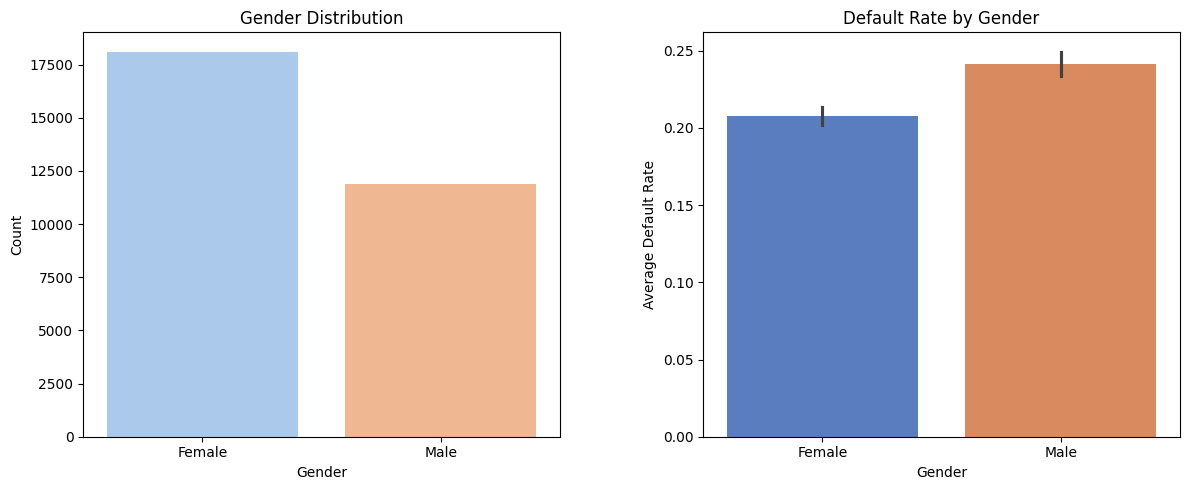

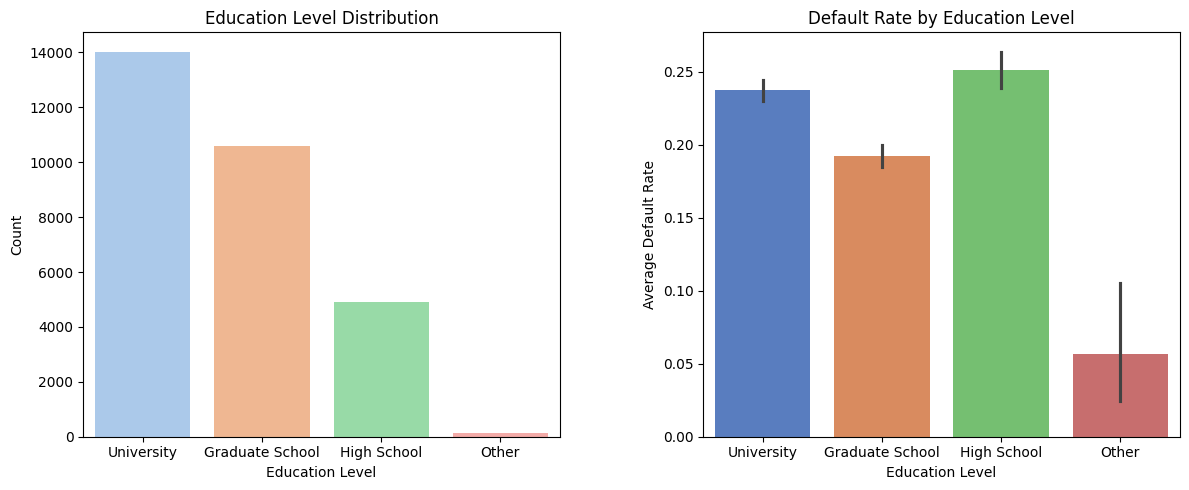

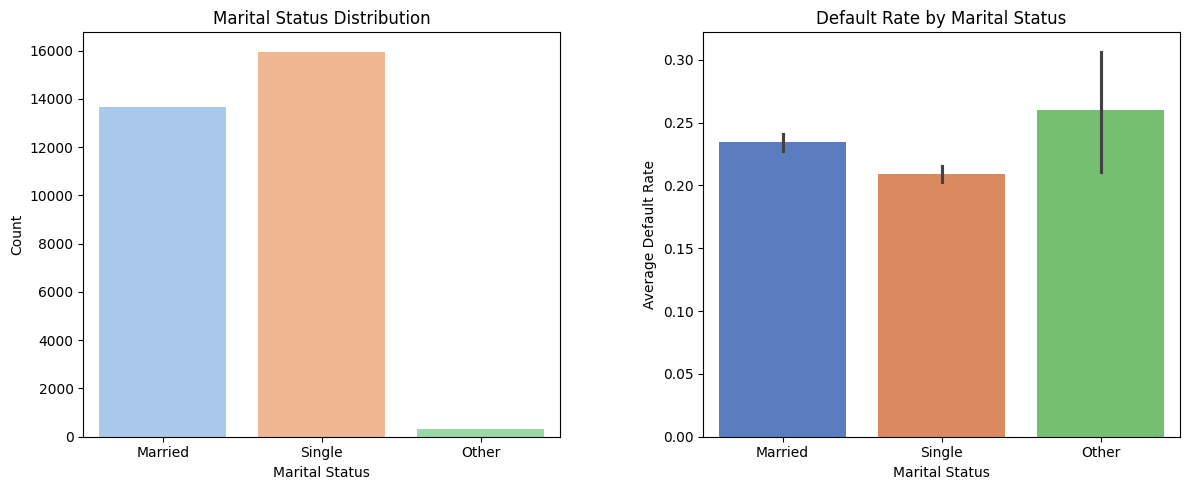

In [12]:
# Define label mappings for readability
sex_labels = {1: "Male", 2: "Female"}
education_labels = {1: "Graduate School", 2: "University", 3: "High School", 4: "Other"}
marriage_labels = {1: "Married", 2: "Single", 3: "Other"}

# Define list of (feature, label mapping, title) tuples
categorical_features = [("SEX", sex_labels, "Gender"), 
                        ("EDUCATION", education_labels, "Education Level"),
                        ("MARRIAGE", marriage_labels, "Marital Status")
                        ]

# Plot distribution and Default Rate side by side for each categorical feature
for feature, labels, title in categorical_features:
    plt.figure(figsize = (12,5))

    # 1) Distribution (counts)
    plt.subplot(1,2,1)
    sns.countplot(x=df[feature].map(labels), hue=df[feature].map(labels), legend=False, palette="pastel")
    plt.title(f"{title} Distribution")
    plt.xlabel(title)
    plt.ylabel("Count")

    # 2) Default Rate by category (proportion of 1s)
    plt.subplot(1,2,2)
    sns.barplot(x=df[feature].map(labels), y=df["default payment next month"], hue=df[feature].map(labels), legend=False, palette="muted")
    plt.title(f"Default Rate by {title}")
    plt.xlabel(title)
    plt.ylabel("Average Default Rate")
   
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()


Analysis of (Nominal) Categorical Features:  

This section examines the relationship between categorical demographic variables - **Gender**, **Education Level**, and **Marital Status** - and the likelihood of defaulting on a credit card payment (`default payment next month`). Each pair of plots presents both the distribution of categories and the average default rate within each group.

**Gender**
- The gender distribution shows that **female clients outnumber male clients** in the dataset.  
- Despite this, **males exhibit a slightly higher average default rate** (around 24%) compared to females (around 21%).  
- This suggests that **gender may have a minor correlation with default behaviour**, though the difference is not likely to be a dominant predictor by itself.  

**Education Level**
- The **largest portion of clients have a university education**, followed by graduate school, while very few belong to the 'other' category.  
- Clients with **high school education have the highest default rate**, whereas those with **graduate school education exhibit the lowest**.  
- This trend implies that **higher education levels are associated with lower default risk**, potentially due to higher and more stable income levels.  

**Marital Status**
- The **majority of clients are single or married**, with a small fraction categorised as 'other'.  
- **Single clients show a marginally higher probability of default** compared to married clients, while the 'other' category is too small to draw reliable conclusions.  
- This observation suggests that **marital status may have a limited but possible influence on credit risk behaviour**.  

Overall Interpretation:

These categorical analyses reveal potential behavioral and demographic patterns in default risk.
- The observed trends (e.g., higher default among males, high school graduates, and single clients) are **useful preliminary indicators** for building predictive models.
- However, because categorical differences are relatively modest and may overlap with numerical effects (e.g., income or credit limit), these features should be validated with **statistical tests** or **machine learning models** to confirm their predictive significance.

## Explore repayment status (ordinal categorical variables) - distribution and default rate

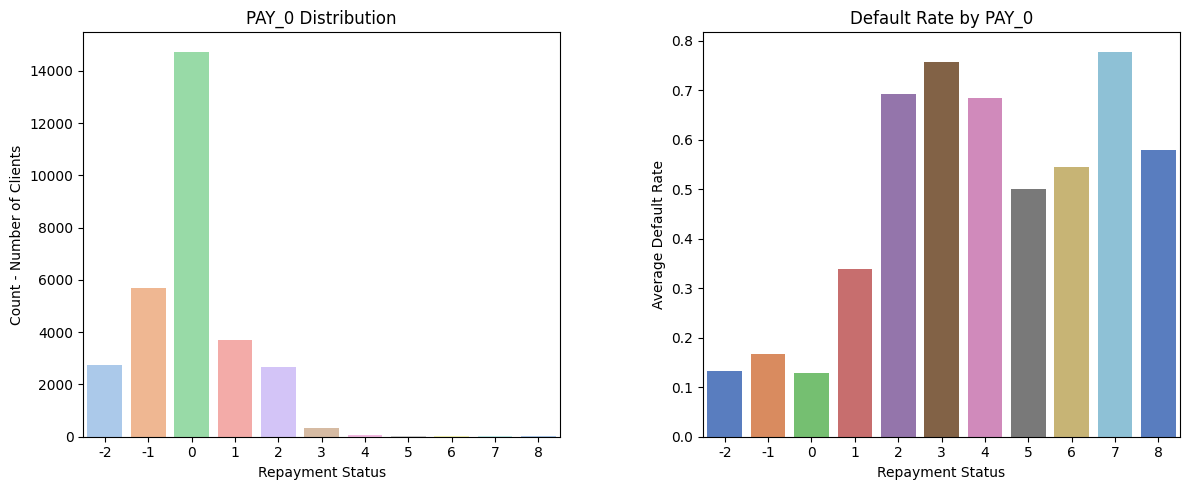

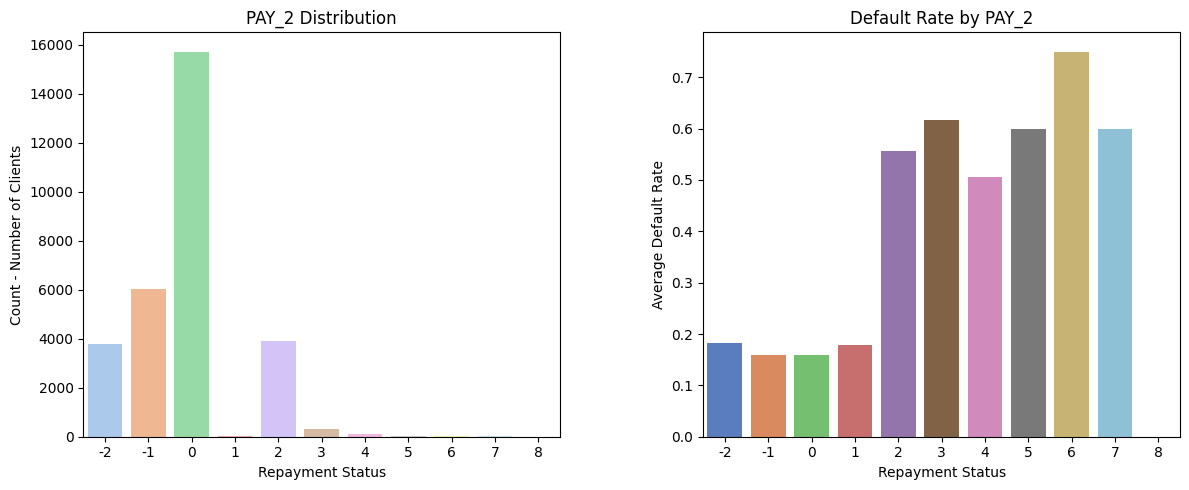

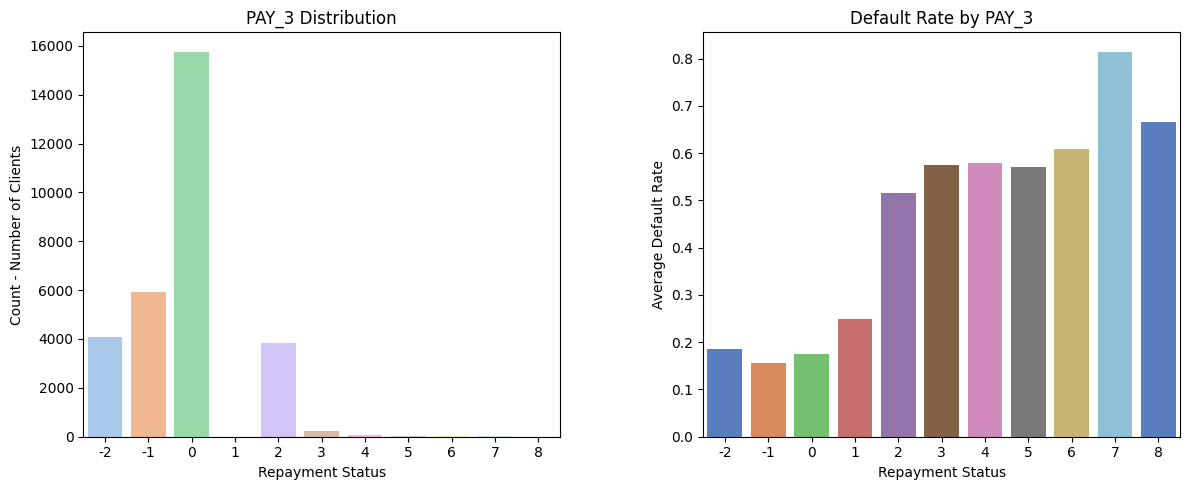

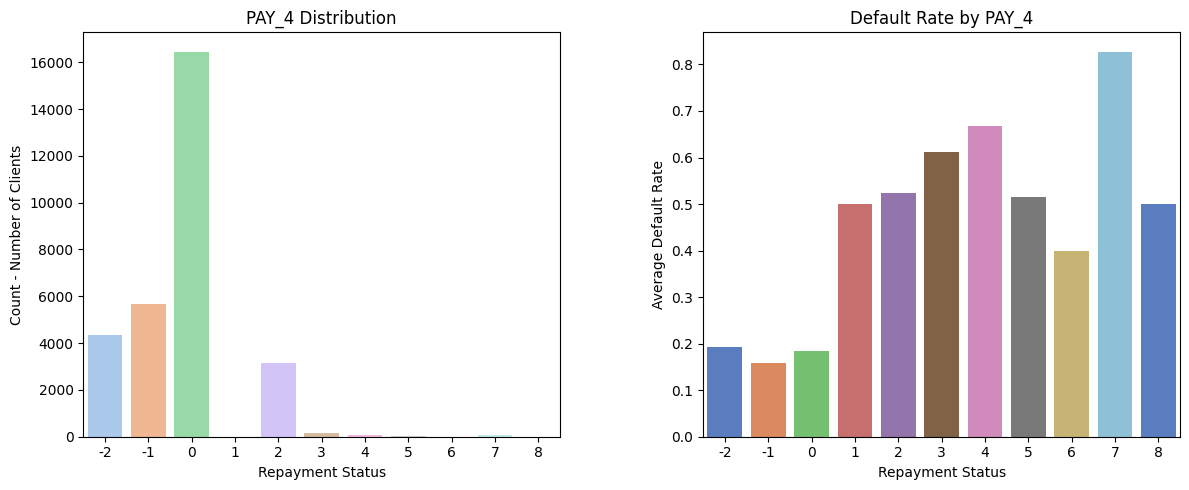

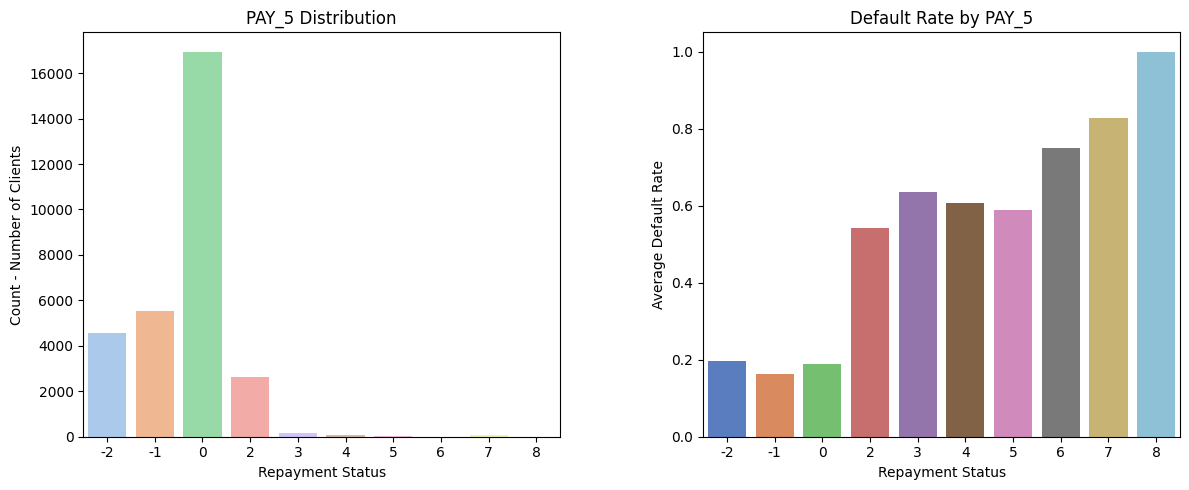

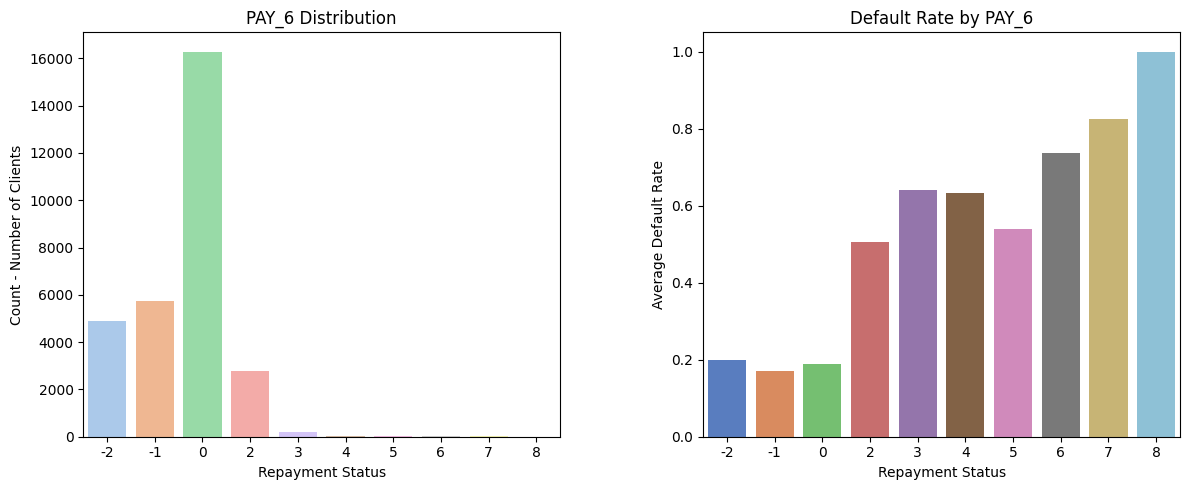

In [13]:
# List of repayment status columns
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    plt.figure(figsize=(12,5))

    # 1) Distribution of repayment status (counts)
    plt.subplot(1,2,1)
    sns.countplot(x=df[col], order=sorted(df[col].unique()), hue=df[col], legend=False, palette="pastel")
    plt.title(f"{col} Distribution")
    plt.xlabel("Repayment Status")
    plt.ylabel("Count - Number of Clients")

    # 2) Default Rate per repayment category (proportion of 1s)
    plt.subplot(1,2,2)
    default_rate = df.groupby(col)["default payment next month"].mean().reset_index()
    sns.barplot(data=default_rate, x=col, y="default payment next month", order=sorted(df[col].unique()), hue=col, legend=False, palette="muted")
    plt.title(f"Default Rate by {col}")
    plt.xlabel("Repayment Status")
    plt.ylabel("Average Default Rate")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show() 

Analysis of (Ordinal) Categorical Features:

**1) OVERVIEW**

The dataset contains repayment history for credit card clients over the 6 months preceding the target month. 
The relevant columns are: `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6`.

*Note: The dataset skips `PAY_1` due to the original column numbering conventions.*  
- `PAY_0` represents the current month.  
- `PAY_2` represents 1 month ago.  
- `PAY_3` represents 2 months ago.  
- ... up to `PAY_6` which represents 5 months ago.  

These columns are ordinal variables representing payment behaviour:
- `-2` -> Paid duly in advance.  
- `-1` -> Paid on time (ahead of schedule).  
- `0` -> Payment on time for that month.
- `1`-``8` -> Payment delayed by 1-8 months.

**2) DISTRIBUTION OF REPAYMENT STATUS**

The bar plots above (on the left) show the distribution clients for each repayment status in each month:
- **Most clients pay on time** (`0`), fewer earlier (`-1`, `-2`).
- Very few clients have delays (positive values), showing **late payments are rare but exist**.
- **The number of clients generally decreases as delay length increases**.
- `PAY_0` (current month) shows the **largest contrast** between on-time and late payments.

**3) DEFAULT RATE BY REPAYMENT STATUS**

The bar plots above (on the right) show the average default rate (default payment next month) for each repayment category:
- **Clients with on-time or early payments (`-2`, `-1`, `0`) have a low default rate.**
    - On-time clients (`0`) have a very low default rate (~10-20%).
- Clients with positive values (payment delays) show increasing default rates as the number of months delayed increases.
- This demonstrates that historical repayment behaviour is strongly predictive of future default.
- Higher `PAY_n` values correspond to greater historical delays.

**4) CONCLUSION**

- Early and on-time payments correspond to low default rates, while late payments correspond to high default rates.
- **Recency effect**: Recent months (`PAY_0`, `PAY_2`) tend to show the most pronounced contrast between on-time and late payments, but older months (PAY_3–PAY_6) still demonstrate a clear increasing trend in default rates with higher delays. Even though past repayment behaviour has a cumulative effect, **the most recent month has the strongest predictive power**.
- High-risk groups: **Clients with repeated delays across multiple months are most likely to default.**
- The repayment status variables (`PAY_0`-`PAY_6`) are strong predictors of default.
- These observations provide valuable insights for risk assessment and predictive modeling.


## Explore age (numerical variable) - distribution and default rate

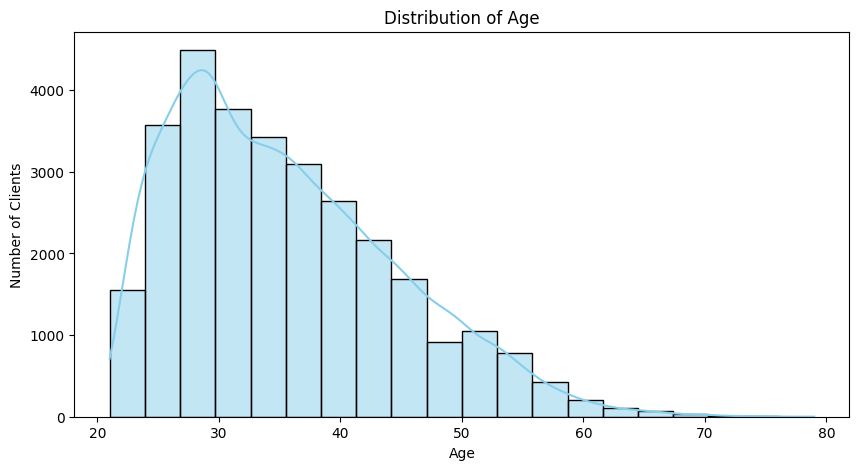

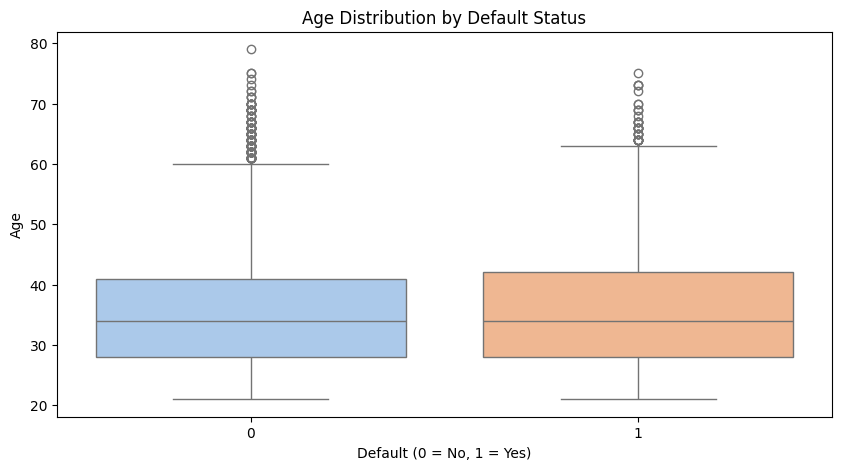

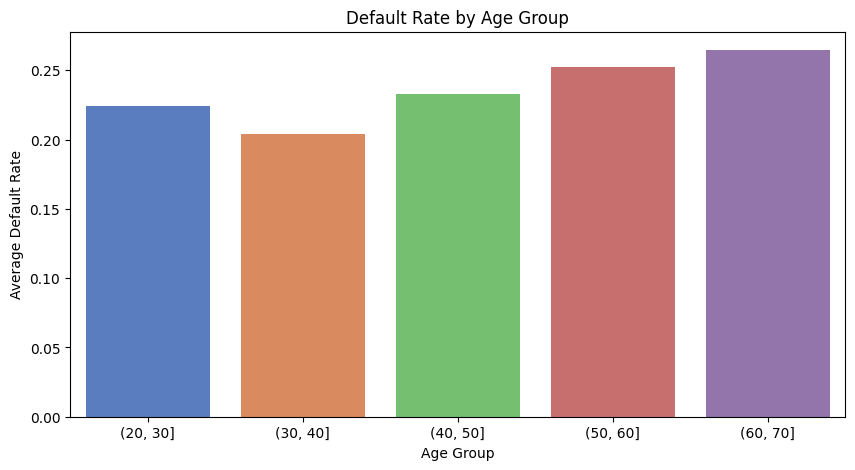

In [14]:
# Age Distribution - Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['AGE'], bins=20, kde=True, color='skyblue') #kde=True overlays a smooth curve to visualise density
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.show()

# Age vs Default Status - Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x='default payment next month', y='AGE', data=df, hue='default payment next month', legend=False, palette='pastel')
plt.title("Age Distribution by Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

# Age bins and Default Rate per bin
age_bins = [20, 30, 40, 50, 60, 70]
df['AGE_BIN'] = pd.cut(df['AGE'], bins=age_bins)
age_default_rate = df.groupby('AGE_BIN', observed=False)['default payment next month'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=age_default_rate, x='AGE_BIN', y='default payment next month', hue='AGE_BIN', legend=False, palette='muted')
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Default Rate")
plt.show()

Age Analysis:

1) **Histogram of Age**
- Shows the distribution of client ages - helps identify if most clients are young, middle-aged, or older.
- Most clients are in the `25-35` age range.
- Therefore, **the dataset is skewed towards younger ages**.

2) **Boxplot of Age by Default Status**
- Compares age distributions for clients who defaulted vs those who did not.
- Highlights any trends, e.g., are younger or older clients more likely to default?
- The minimum, lower quartile and median are very similar for defaulters and non-defaulters.
- But the maximum and upper quartile are higher for defaulters, meaning the IQR is also higher.
- This suggests that **among the clients who defaulted, there are more older individuals compared to the non-defaulters**.
- The presence of older defaulters may indicate financial stress or credit overextension.
- Therefore, **default is not limited to younger clients**.

3) **Age bins**
- Groups ages into ranges (e.g., `20-30`, `30-40`) for easier interpretation.
- Bar plot shows average default rate per age group, which is intuitive for reports.
- We know from the histogram that young clients dominate in number - so most defaults numerically come from them. But, proportionately, older clients may have slightly higher default rates. We can check this with the age-bin default rates.
- The age bins show that the **age range `30-40` (~20.5%) have the lowest default rates**, `20-30` slightly higher but still second lowest.
- The **default rates increase with age** (excluding `30-40`), with the **age range `60-70` having the highest rates (~26.5)**.


## Explore credit limit balance (numerical variable) - distribution and default rate

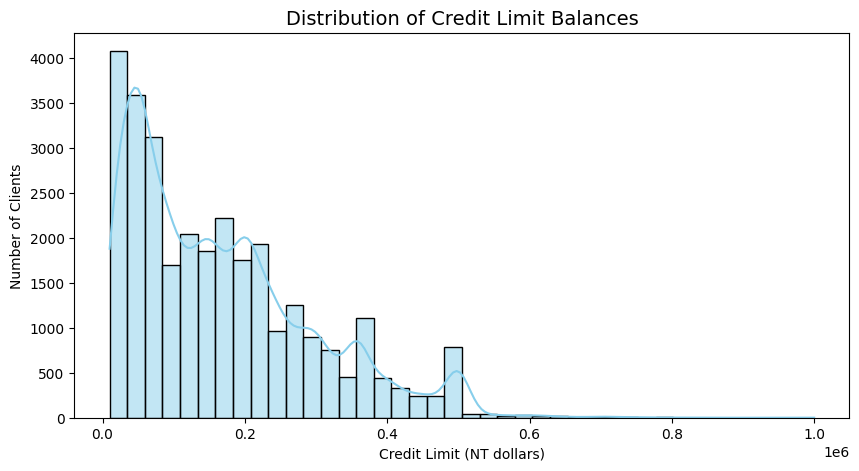

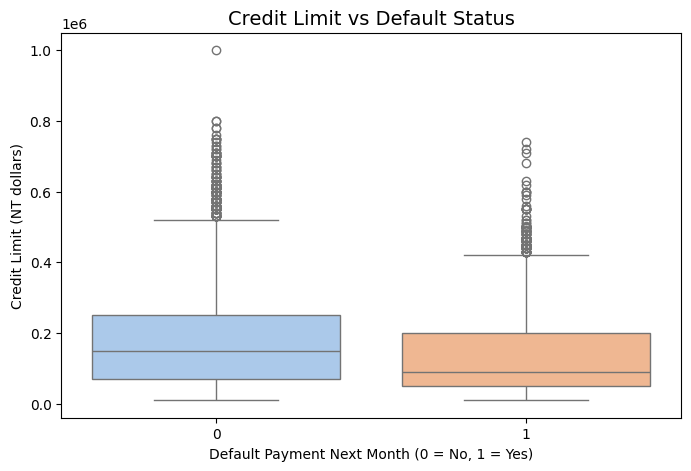

,default payment next month,count,mean,std,min,25%,50%,75%,max
0,0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


In [17]:
# Credit Limit Balance Distribution - Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['LIMIT_BAL'], bins=40, kde=True, color='skyblue')
plt.title("Distribution of Credit Limit Balances", fontsize=14)
plt.xlabel("Credit Limit (NT dollars)")
plt.ylabel("Number of Clients")
plt.show()

# Credit Limit vs Default Status - Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df, hue='default payment next month', legend=False, palette="pastel")
plt.title("Credit Limit vs Default Status", fontsize=14)
plt.xlabel("Default Payment Next Month (0 = No, 1 = Yes)")
plt.ylabel("Credit Limit (NT dollars)")
plt.show()

# Summary Statistics by Default Status
limit_summary = df.groupby('default payment next month')['LIMIT_BAL'].describe().reset_index()
limit_summary


Credit Limit Balance Analysis:

1) **Distribution of Credit Limits - Histogram Analysis**
- The distribution is strongly right-skewed.
- Most clients have a relatively low to moderate credit limit, typically between NT$50,000 and NT$200,000.
- As the credit limit increases, the number of clients decreases sharply, with very few clients having limits above NT$500,000.
- This pattern is expected in real-world credit data because higher limits are only given to individuals with stronger financial profiles.

2) **Credit Limit vs Default Status - Boxplot Analysis**
- The boxplot shows a clear separation between the two groups.
    - Non-defaulters (0) have noticeably higher median credit limits and a wider interquartile range, suggesting greater financial stability.
    - Defaulters (1) tend to have significantly lower credit limits, implying that customers with limited credit capacity are at higher risk of repayment difficulties.
- There are still outliers in both groups with very high credit limits, but these are rare and do not alter the overall trend.
- This suggests a relationship where clients with stronger financial capacity (higher limits) are less likely to default.
- Overall, the analysis indicates that credit limit is a meaningful predictor of default risk.



## Explore bill amounts (numerical variable) - distribution and default rate

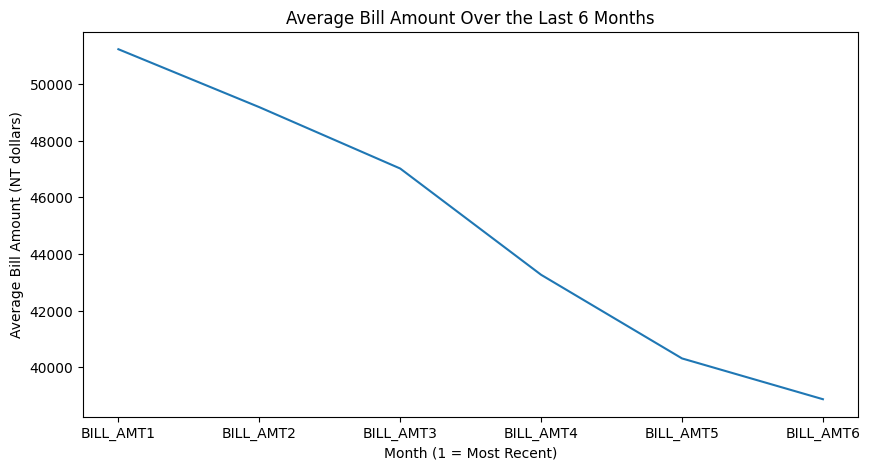

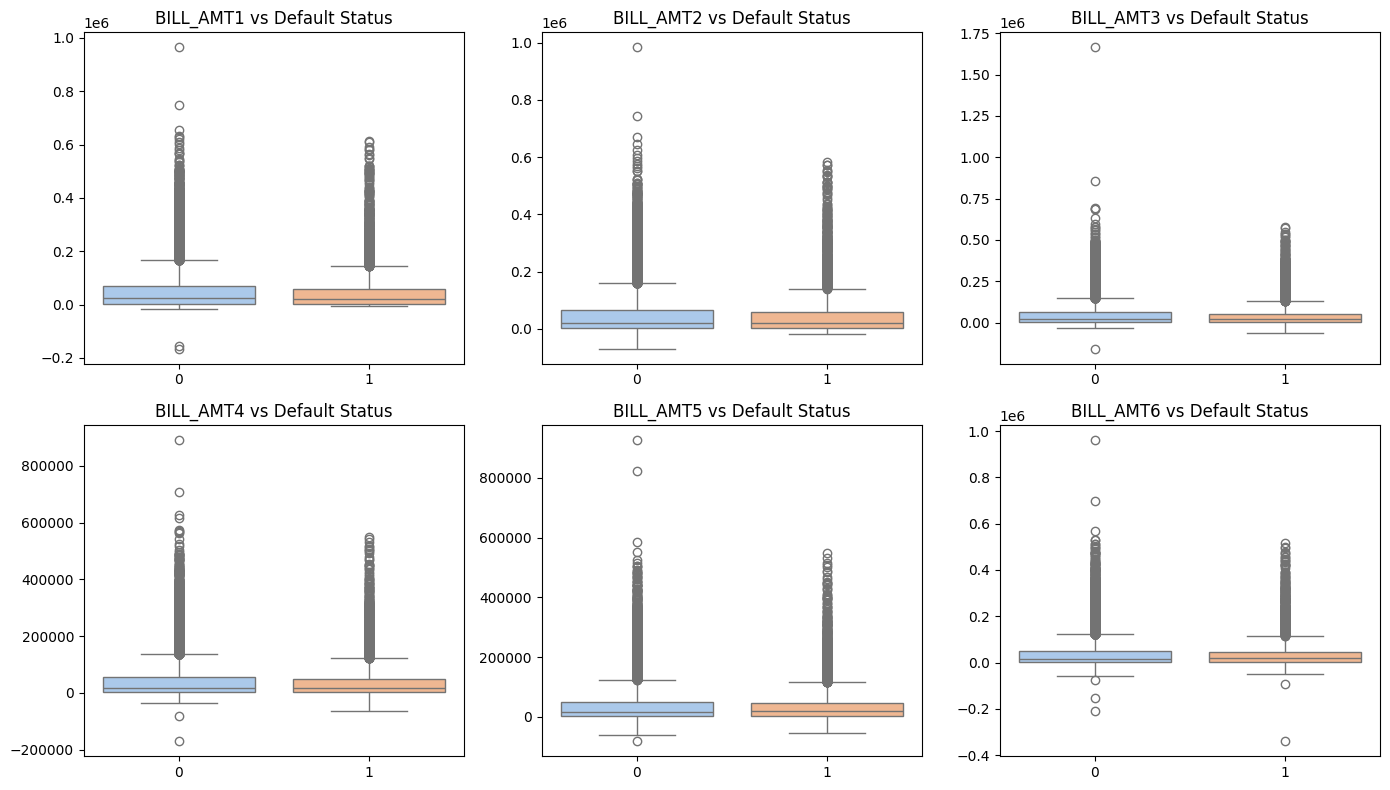

default payment next month,0,1
BILL_AMT1,51994.227273,48509.162297
BILL_AMT2,49717.435670,47283.617842
BILL_AMT3,47533.365605,45181.598855
BILL_AMT4,43611.165254,42036.950573
BILL_AMT5,40530.445343,39540.190476
BILL_AMT6,39042.268704,38271.435503


In [19]:
# Average bill amounts over time - Line plot

bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']

bill_means = df[bill_cols].mean() # Calculate mean bill amount per month

plt.figure(figsize=(10,5))
sns.lineplot(x=bill_cols, y=bill_means)
plt.title("Average Bill Amount Over the Last 6 Months")
plt.xlabel("Month (1 = Most Recent)")
plt.ylabel("Average Bill Amount (NT dollars)")
plt.show()

# Bill Amounts by Default Status - Boxplot

plt.figure(figsize=(14,8))
for i, col in enumerate(bill_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='default payment next month', y=col, hue='default payment next month', legend=False, palette="pastel")
    plt.title(f"{col} vs Default Status")
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout()
plt.show()

# Summary Statistics by Default Status

bill_summary = df.groupby('default payment next month')[bill_cols].mean().T
bill_summary

Analysis of Bill Amounts

1) **Average Bill Amounts over time**
- The line plot shows that average bill amounts follow a fairly consistent pattern across the six months.
- The values fluctuate but do not show any dramatic upward or downward trends, suggesting that most clients maintain relatively stable statement balances over time.
- Interestingly, the most recent bill (`BILL_AMT1`) is not necessarily the highest or lowest - indicating that clients' spending patterns do not dramatically shift month-to-month.
- This stability can be useful for modelling, as past behaviour appears predictive of future bills.

2) **Bill Amounts vs Default Status**
- Defaulteres tend to have higher bill amounts on average.
    - The median bill amount is generally (across all six months) higher for clients who default.
    - The upper quartile tends to be larger for defaulters, indicating more high-balance individuals.
    - Defaulters also show more extreme positive outliers, meaning some maintain very large unpaid balances month after month.
- Non-defaulters have lower and more stable balances.
    - The IQR (box height) tend to be smaller.
    - Their medians are consistently lower.
- This suggests that consistently high credit card balances may be a risk factor for default.

3) **Summary Statistics Interpretation**
- Defaulters have higher mean bill amounts for nearly every month.
- The difference is noticeable but not extreme - indicating it's a supporting predictor, not the main one.
- The pattern is consistent: higher outstanding balances -> higher likelihood of default.
- This makes sense, as clients struggling to repay tend to accumulate larger unpaid amounts.

## Explore payment amounts (numerical variable) - distribution and default rate

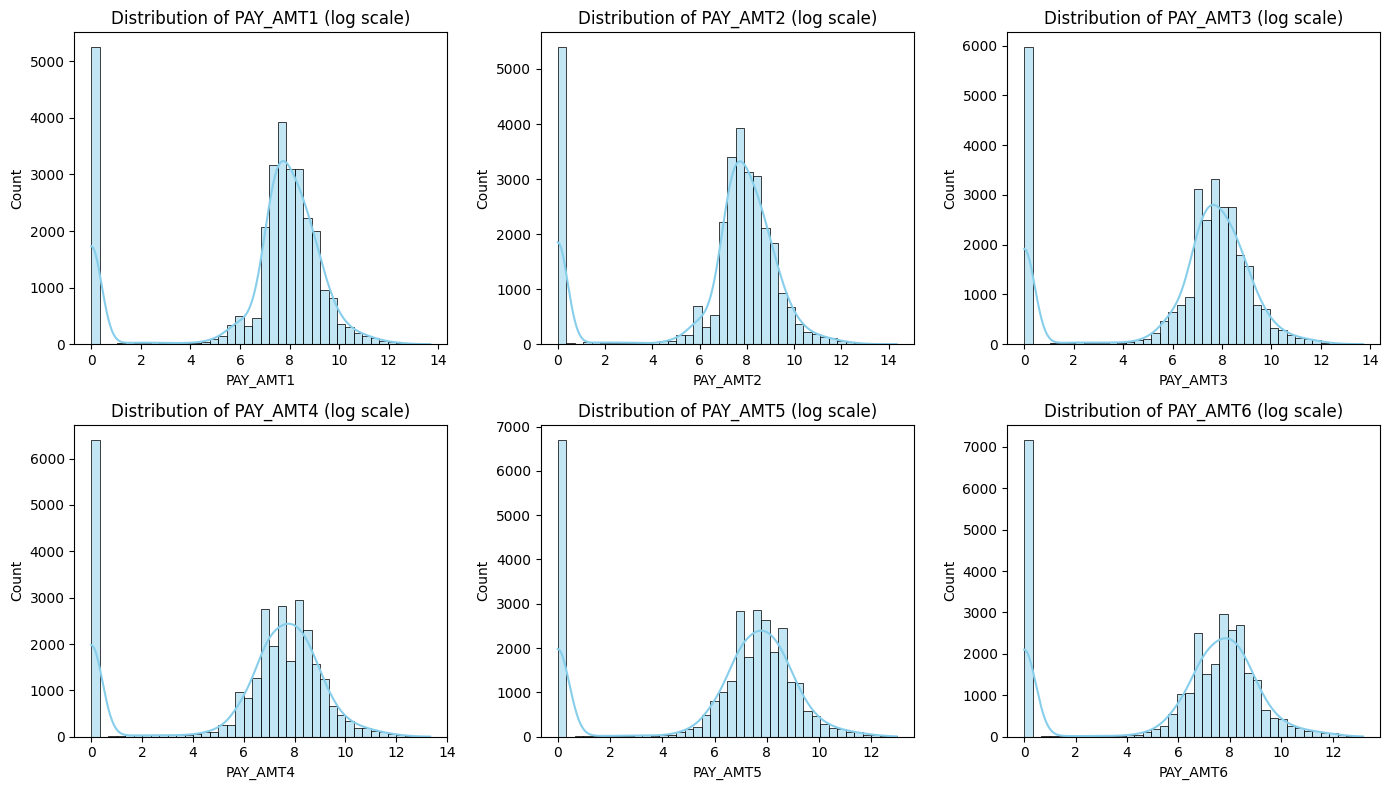

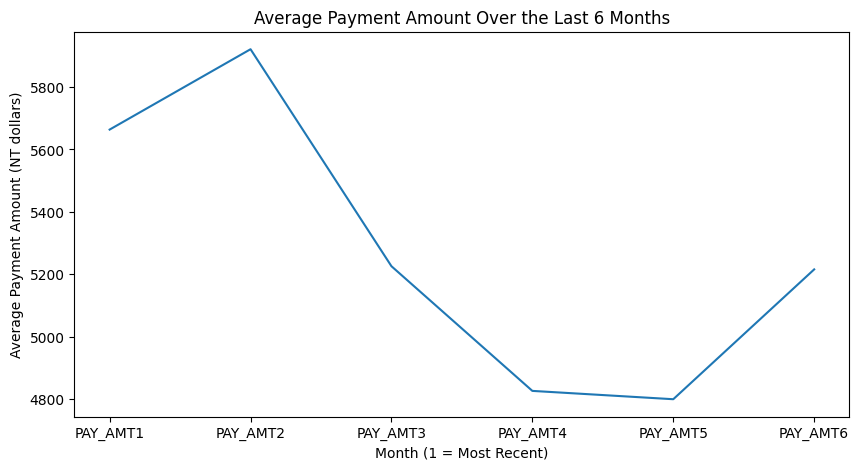

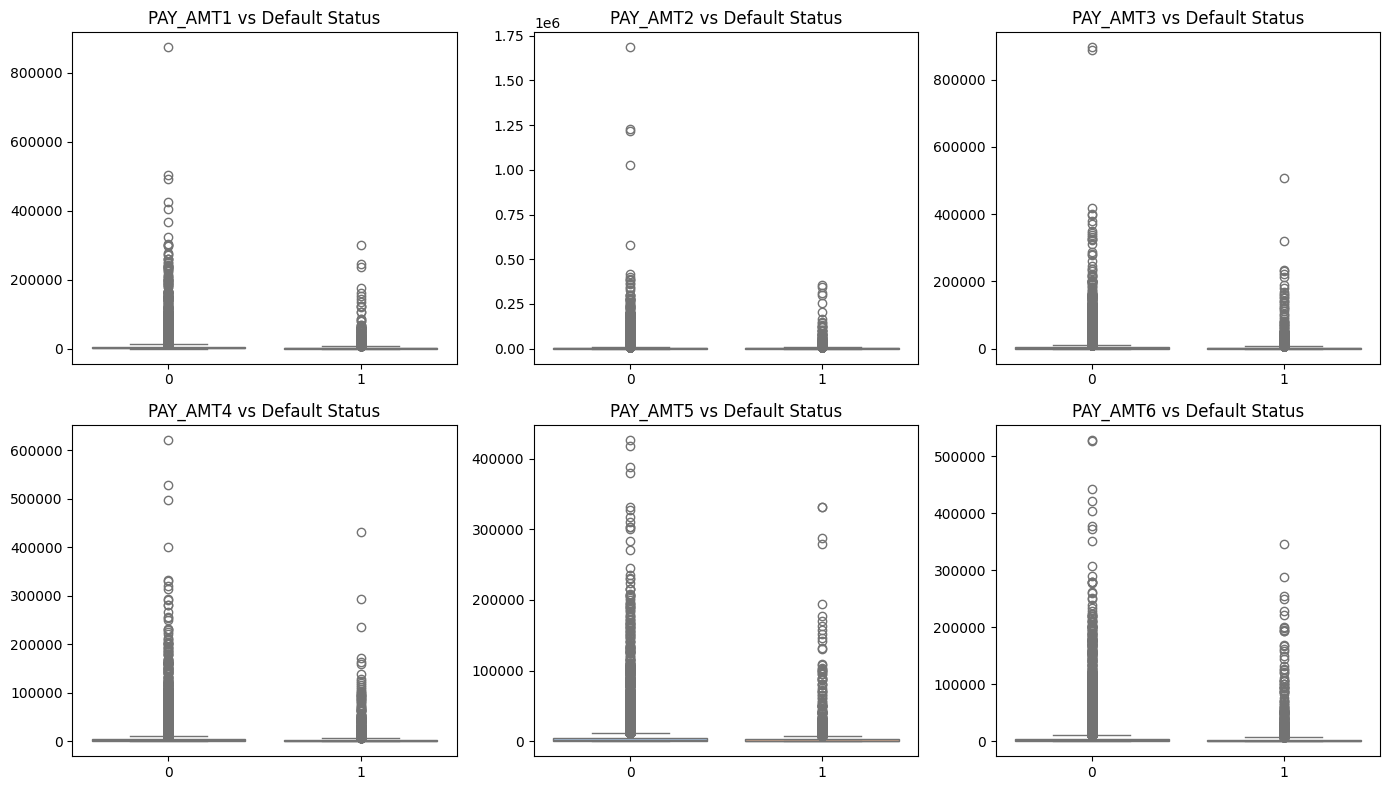

default payment next month,0,1
PAY_AMT1,6307.337357,3397.044153
PAY_AMT2,6640.465074,3388.649638
PAY_AMT3,5753.496833,3367.351567
PAY_AMT4,5300.529319,3155.626733
PAY_AMT5,5248.220296,3219.139542
PAY_AMT6,5719.371769,3441.482068


In [20]:
# Payment Amounts Distribution - Histogram

pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

plt.figure(figsize=(14,8))
for i, col in enumerate(pay_amt_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(np.log1p(df[col]), bins=40, kde=True, color='skyblue')
    plt.title(f"Distribution of {col} (log scale)")
plt.tight_layout()
plt.show()

# Average Payment Amount over time - Line Plot

pay_means = df[pay_amt_cols].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=pay_amt_cols, y=pay_means)
plt.title("Average Payment Amount Over the Last 6 Months")
plt.xlabel("Month (1 = Most Recent)")
plt.ylabel("Average Payment Amount (NT dollars)")
plt.show()

# Payment Amounts vs Default Status

plt.figure(figsize=(14,8))
for i, col in enumerate(pay_amt_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='default payment next month', y=col, hue='default payment next month', legend=False, palette="pastel")
    plt.title(f"{col} vs Default Status")
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout()
plt.show()

# Summary Table

payment_summary = df.groupby('default payment next month')[pay_amt_cols].mean().T
payment_summary


Payment Amounts Analysis

1) ....

## Correlation Analysis
Helps identify
- Which variables are related to each other (multicollinearity)
- Which variables are most associated with the default outcome
- Redundant features that model algorithms might penalise

In [23]:
# Compute Correlation Matrix
num_df = df.select_dtypes(include=['number']) # Select only numeric columns (doesn't work with categorical columns - age-bin is categorical)
corr_matrix = num_df.corr()
corr_matrix


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
LIMIT_BAL,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614
PAY_5,-0.249411,-0.055064,0.097520,0.035629,-0.053826,0.509426,0.622780,0.686775,0.819835,1.000000,...,0.271915,0.269783,0.262509,-0.006089,-0.003191,0.009062,-0.058299,-0.033337,-0.023027,0.204149


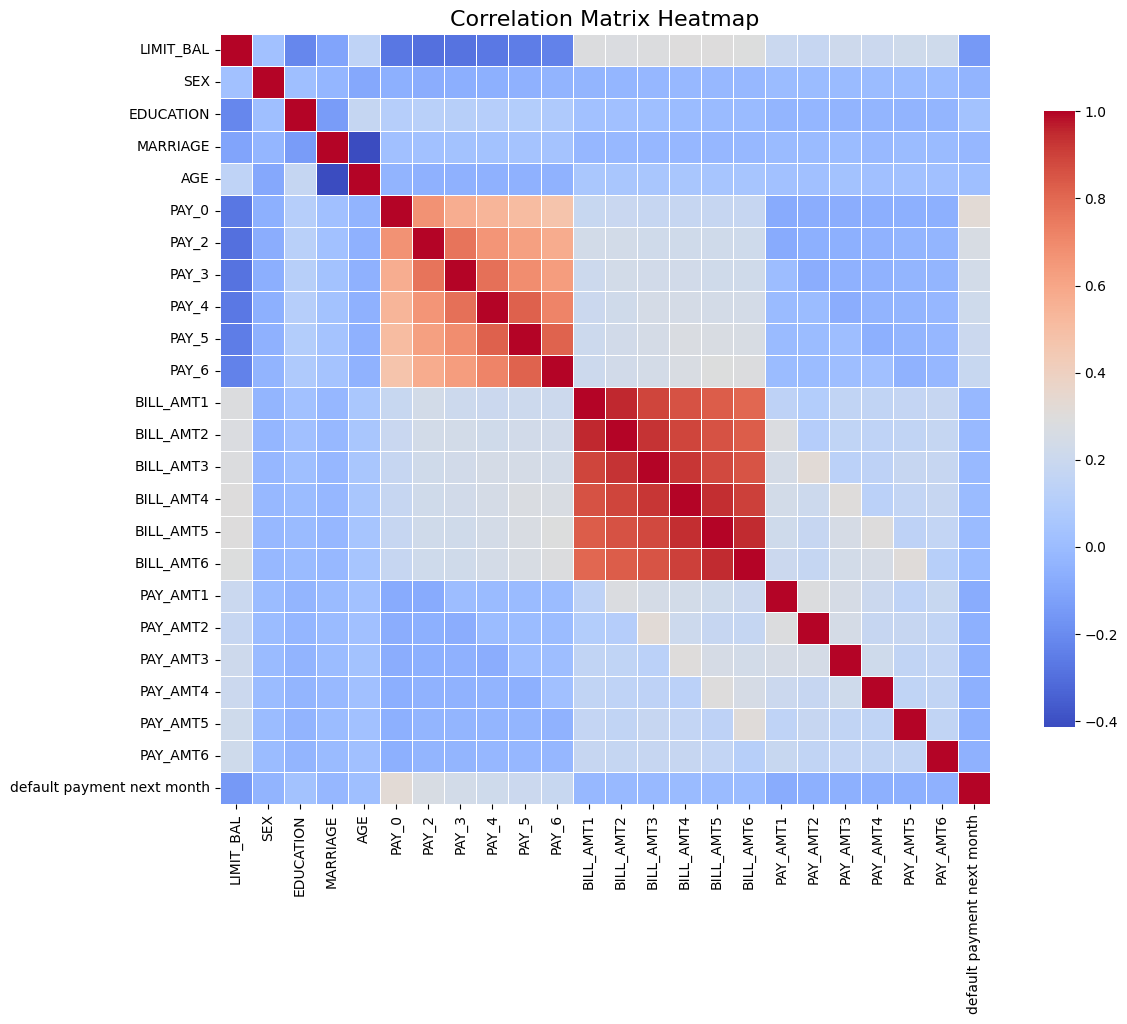

In [ ]:
# Plot a Correlation Heatmap (Seaborn)
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False, # annot=True means printed values but too cluttered with this large dataset. So annot=False for readability
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()


In [ ]:
# Find the Top Correlations with Target Variable
target_corr = corr_matrix["default payment next month"].sort_values(ascending=False)
target_corr


default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default payment next month, dtype: float64